In [1]:
import numpy as np
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # 0 = all logs, 1 = filter INFO, 2 = filter WARNING, 3 = filter ERROR
os.chdir('/groups/SUDOCO/Task23/sudoco_task2.3/')
from surrogates_interface.transformers import Transformer
import matplotlib.pyplot as plt
from surrogates_interface.surrogates import TensorFlowModel
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import numpy as np
import pandas as pd
import xarray as xr
from py_wake.site import UniformSite
# from py_wake.wind_farm_models.engineering_models import PropagateDownwind
from py_wake.examples.data.hornsrev1 import V80
# from dependencies import compute_sector_average, PropagateDownwindNoSelfInduction, predict_loads_sector_average
from wind_farm_loads.py_wake import  PropagateDownwindNoSelfInduction, predict_loads_sector_average, predict_loads_rotor_average
from wind_farm_loads.tool_agnostic import compute_sector_average
from abc import ABC
from py_wake.deficit_models import ZongGaussianDeficit, NOJDeficit
from py_wake.deflection_models.jimenez import JimenezWakeDeflection
from py_wake.flow_map import HorizontalGrid
from py_wake.site._site import UniformSite
from py_wake.site.shear import PowerShear
from py_wake.turbulence_models import CrespoHernandez, GCLTurbulence,STF2017TurbulenceModel
# from py_wake.deficit_models.gaussian import GaussianDeficit
from py_wake.site import UniformSite
from py_wake.examples.data.hornsrev1 import V80, Hornsrev1Site
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Hides INFO and WARNING messages
import tensorflow as tf
tf.get_logger().setLevel('ERROR')         # Hides tf.function retracing warnings
from iea3_4_pywake_openfast_1 import iea3_4
from py_wake.wind_turbines.power_ct_functions import PowerCtTabular
from py_wake.wind_turbines import WindTurbine, WindTurbines
from data.turbine.iea_22s import IEA22s
from py_wake.deficit_models.gaussian import ZongGaussianDeficit
from py_wake.superposition_models import WeightedSum, SqrMaxSum
from py_wake.wind_farm_models import PropagateDownwind
from py_wake.turbulence_models import CrespoHernandez
from py_wake.deflection_models.jimenez import JimenezWakeDeflection
from py_wake.site._site import UniformSite
from py_wake.deficit_models.utils import ct2a_mom1d
from data.turbine.iea_22s import IEA22s
from py_wake.wind_turbines.power_ct_functions import PowerCtFunctionList, PowerCtTabular
from py_wake.rotor_avg_models import RotorCenter, GridRotorAvg, EqGridRotorAvg, GQGridRotorAvg, CGIRotorAvg, PolarGridRotorAvg, PolarRotorAvg, polar_gauss_quadrature, GaussianOverlapAvgModel
from py_wake.flow_map import HorizontalGrid


# Updated list of available surrogate channels based on files you have
channels = [
    "SA_blade_root_ip", "SA_blade_root_oop","SA_blade_root_projected", "SA_shaft_oop", "SA_shaft_yaw",
    "SA_tbss", "SA_tbfa", "SA_tower_top_fa", "SA_tower_torsion","SA_tower_top_ss","SA_tower_base_projected"
]

channels_RA = [
    "RA_blade_root_ip", "RA_blade_root_oop","RA_blade_root_projected", "RA_shaft_oop", "RA_shaft_yaw",
    "RA_tbss", "RA_tbfa", "RA_tower_top_fa", "RA_tower_torsion","RA_tower_top_ss","RA_tower_base_projected"
]

channels_IEA22 = [
    "RA_ADC", "RA_BRM","RA_ebrm", "RA_fbrm", "RA_blade_torsion", "RA_tbfa",
    "RA_tbss", "RA_TBM", "RA_ttfa", "RA_TTM","RA_gsb_l10","RA_rsb_l10","RA_shaft_mx_mb_fixed","RA_shaft_mz_mb_fixed"
]

surrogates = {}
for ch in channels:
    model_path = os.path.join("models/SA_surrogate_IEA34", f"{ch}.keras")
    scaler_path = os.path.join("models/SA_surrogate_IEA34", f"scaler_{ch}.h5")
    # surrogates[ch] = TensorFlowModel(model_path, scaler_path)
    surrogates[ch] = TensorFlowModel.load_h5(
    model_path=model_path, extra_data_path=scaler_path)


surrogates_rotor = {}
for ch in channels_RA:
    model_path = os.path.join("models/RA_surrogate_IEA34", f"{ch}.keras")
    scaler_path = os.path.join("models/RA_surrogate_IEA34", f"scaler_{ch}.h5")
    # surrogates[ch] = TensorFlowModel(model_path, scaler_path)
    surrogates_rotor[ch] = TensorFlowModel.load_h5(
    model_path=model_path, extra_data_path=scaler_path)

surrogates_IEA22 = {}
for ch in channels_IEA22:
    model_path = os.path.join("models/RA_IEA22_DTU", f"{ch}.keras")
    scaler_path = os.path.join("models/RA_IEA22_DTU", f"scaler_{ch}.h5")
    # surrogates[ch] = TensorFlowModel(model_path, scaler_path)
    surrogates_IEA22[ch] = TensorFlowModel.load_h5(
    model_path=model_path, extra_data_path=scaler_path)

2025-07-25 13:07:05.417129: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753441625.479343   20697 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753441625.496843   20697 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753441625.605579   20697 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753441625.605622   20697 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753441625.605625   20697 computation_placer.cc:177] computation placer alr

In [2]:
# # plot power curves
# wt = IEA22s()
# wt.powerCtFunction = PowerCtFunctionList(
#     key="operating",
#     powerCtFunction_lst=[
#         PowerCtTabular(
#             ws=[0, 100], power=[0, 0], power_unit="w", ct=[0, 0]
#         ),  # 0=No power and ct
#         IEA22s().powerCtFunction,
#     ],  # 1=Normal operation
#     default_value=1,
# )
# u = np.arange(3,26)
# plt.figure()
# for op in [0,1]:
#     plt.plot(u, wt.power(u, operating=op)/1000, label=f'Operating={op}')
# plt.xlabel('Wind speed $u$ (m/s)')    # X-axis label
# plt.ylabel('Power output (kW)')       # Y-axis label
# plt.grid(True)      
# plt.figure()
# for op in [0,1]:
#     plt.plot(u, wt.ct(u, operating=op), label=f'Operating={op}')
# plt.xlabel('Wind speed $u$ (m/s)')    # X-axis label
# plt.ylabel('t')       # Y-axis label
# plt.grid(True) 


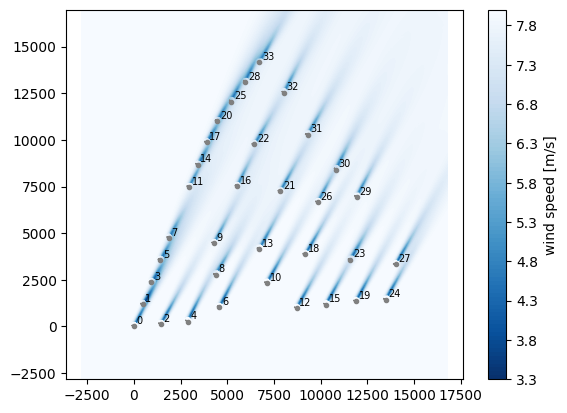

In [3]:
# Example with IEA22 turbines in the flow and IEA 3.4 for the surrogates

# %%prun
wt = IEA22s()

# First approach of creating two turbine types one shut and one the normal turbine
u = [0,3,12,25,30]
ct = [0,0,0,0, 0]
power = [0,0,0,0,0]

wt2 = WindTurbine(name='MyWT',
                    diameter=wt.diameter(),
                    hub_height=wt.hub_height(),
                    powerCtFunction=PowerCtTabular(u,power,'kW',ct))
wts = WindTurbines.from_WindTurbine_lst([wt2, wt])

# Second approach of creating a single turbine with operating modes
wt.powerCtFunction = PowerCtFunctionList(
    key="operating",
    powerCtFunction_lst=[
        PowerCtTabular(
            ws=[0, 100], power=[0, 0], power_unit="w", ct=[0, 0]
        ),  # 0=No power and ct
        IEA22s().powerCtFunction,
    ],  # 1=Normal operation
    default_value=1,
)
# Then to run it I need something like this
# # sim_res_zong_weighted = wf_model(
#     x, y, wd=270, ws=7, TI=0.06, yaw=0, tilt=0, operating=np.array([0, 0, 1, 1])
# )


# Wind farm layout
D = wt.diameter()


# models pywake
deficit_model = ZongGaussianDeficit(
    a=[0.38, 4e-3],
    deltawD=1.0 / np.sqrt(2),
    eps_coeff=0.35,
    lam=7.5,
    B=3,
    rotorAvgModel=CGIRotorAvg(21),
    groundModel=None,
    use_effective_ws=True,
    use_effective_ti=True,
)

turbulence_model = CrespoHernandez(
    ct2a=ct2a_mom1d,
    c=[0.73, 0.83, 0.03, -0.32],
    addedTurbulenceSuperpositionModel=SqrMaxSum(),
)

site = UniformSite(shear=PowerShear(h_ref=wt.hub_height(), alpha=0.2))


# Wind farm model (no self induction)
wfm = PropagateDownwindNoSelfInduction(
    site=site,
    windTurbines=wts,
    wake_deficitModel=deficit_model,
    superpositionModel=WeightedSum(),
    deflectionModel=JimenezWakeDeflection(),
    turbulenceModel=turbulence_model,
)


# site.ds
layout_subset = pd.read_csv(r"data/HKN_layout_subset_with_scaled.csv")
x_scaled = layout_subset["x_scaled"]
y_scaled = layout_subset["y_scaled"]


repeat_fac= 1
# yaw_ang= np.full(34, 0)
# power_level=np.full(34, 100)
yaw_ang = np.random.uniform(-10, 10, size=(34,repeat_fac))
power_level = np.random.uniform(50, 100, size=(34,repeat_fac))
sim_res = wfm(
    x=x_scaled,
    y=y_scaled,
    type=np.full(34, True),  # Only first three turbines are active
    TI=np.full(repeat_fac, 0.1),            # single turbulence intensity
    wd=np.full(repeat_fac, 208),              # single wind direction
    ws=np.full(repeat_fac, 8),              # single wind speed
    yaw=yaw_ang,        # array yaw values
    tilt=np.full(34, 0),      # array of tilt values
    time=True,
    # power_demand=power_level,     # array of power level values works only if the turbine has power levels defined
)

sim_res.flow_map().plot_wake_map()  # this will take a long time


# sim_res

In [4]:
# %%prun
# --------------------------------------
# Predict loads using rotor-averaged inflow (alternative)
# --------------------------------------
# This uses the same surrogates, but calls the rotor-average function.
# Make sure your surrogates are trained for rotor-averaged inputs!
loads_rotor = predict_loads_rotor_average(
    surrogates_rotor,
    sim_res,                      # the PyWake SimulationResult
    yaw_ang,              # yaw array (example)
    power_level,             # power demand array (example)
    ti_in_percent=True,           # same flag as sector-averaged
    dtype=np.float64             # output dtype
)

# print("\n=== Rotor-Averaged Loads ===")
# print(loads_rotor)


In [5]:
# %%prun
sa = compute_sector_average(sim_res, 
                            n_radius=10,
    n_azimuth=73,
    look="downwind",
    use_single_precision=True,
    )

In [6]:
# Predict loads using sector-averaged inflow
loads_sector = predict_loads_sector_average(
    surrogates,   # dictionary of TensorflowSurrogate objects
    # sim_res,      # simulation result from PyWake
    sa,           # sector-averaged inflow (the variable `sa`)
    yaw_ang,              # yaw array (example)
    power_level,             # power demand array (example)
    ti_in_percent=True,
)

In [7]:
# drop the length-1 “time” dim
da = loads_sector.squeeze()  

# now da.dims == ("wt","name")
# build your DataFrame exactly as before:
df = pd.DataFrame(
    da.values,
    columns=da.coords["name"].values,
    index=[f"T{i}" for i in range(da.sizes["wt"])]
)

print(df)


     SA_blade_root_ip  SA_blade_root_oop  SA_blade_root_projected  \
T0           4.614027           2.459505                 4.688094   
T1           4.271556           3.235003                 4.302616   
T2           4.581727           2.495392                 4.634082   
T3           4.361247           3.219097                 4.436337   
T4           4.634569           2.526940                 4.718588   
T5           4.445301           3.547215                 4.583598   
T6           4.637594           2.631294                 4.735499   
T7           4.480555           3.044790                 4.575490   
T8           4.620144           3.267933                 4.757249   
T9           4.654709           2.799685                 4.828960   
T10          4.584021           2.528426                 4.634381   
T11          4.610187           3.047353                 4.827013   
T12          4.564600           2.310764                 4.607573   
T13          4.622015           2.

In [8]:
# drop the length-1 “time” dim
da = loads_rotor.squeeze()  

# now da.dims == ("wt","name")
# build your DataFrame exactly as before:
df = pd.DataFrame(
    da.values,
    columns=da.coords["name"].values,
    index=[f"T{i}" for i in range(da.sizes["wt"])]
)

print(df)


     RA_blade_root_ip  RA_blade_root_oop  RA_blade_root_projected  \
T0           4.576475           2.548693                 4.574140   
T1           4.487760           3.472518                 4.941728   
T2           4.514329           2.139385                 4.471283   
T3           4.472932           3.350928                 4.840479   
T4           4.611500           2.354718                 4.667870   
T5           4.657697           3.276330                 4.994136   
T6           4.573223           2.647667                 4.557972   
T7           4.531783           3.024578                 4.723268   
T8           4.525066           3.400836                 4.971393   
T9           4.745514           3.337583                 4.983127   
T10          4.513705           2.159269                 4.476213   
T11          4.720322           3.216361                 5.032749   
T12          4.531467           2.297493                 4.526120   
T13          4.619909           3.

<xarray.SimulationResult> Size: 448B
Dimensions:       (wt: 4, time: 1)
Coordinates:
  * wt            (wt) int64 32B 0 1 2 3
    wd            (time) int64 8B 270
    ws            (time) int64 8B 8
    type          (wt) int64 32B 1 1 1 1
  * time          (time) int64 8B 0
Data variables: (12/15)
    WS_eff        (wt, time) float64 32B 8.0 6.825 6.456 6.673
    TI_eff        (wt, time) float64 32B 0.1 0.1583 0.1753 0.1583
    Power         (wt, time) float64 32B 1.553e+06 1.163e+06 8.166e+05 1.087e+06
    CT            (wt, time) float64 32B 0.7209 0.8164 0.7209 0.8164
    yaw           (wt) int64 32B 20 0 20 0
    tilt          (wt) int64 32B 0 0 0 0
    ...            ...
    y             (wt) float64 32B 650.0 650.0 650.0 650.0
    WD            int64 8B 270
    TI            float64 8B 0.1
    wd_bin_size   float64 8B 360.0
    WS            float64 8B 8.0
    P             float64 8B 1.0

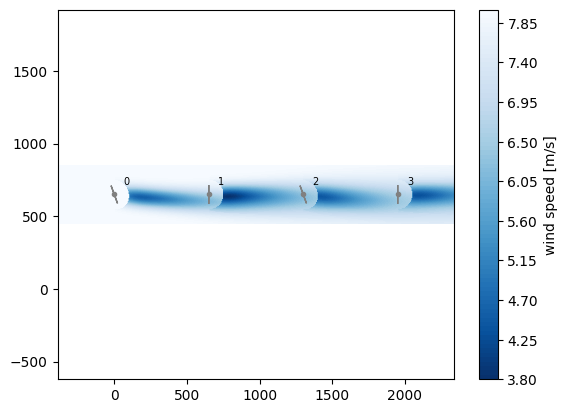

In [9]:
#IEA34 example

# %%prun
wt = iea3_4

u = [0,3,12,25,30]
ct = [0,0,0,0, 0]
power = [0,0,0,0,0]

wt2 = WindTurbine(name='MyWT',
                    diameter=wt.diameter(),
                    hub_height=wt.hub_height(),
                    powerCtFunction=PowerCtTabular(u,power,'kW',ct))
wts = WindTurbines.from_WindTurbine_lst([wt2, wt])

# Wind farm layout
D = wt.diameter()
x_turbines = np.array([0.0, 5, 10, 15]) * D  # [m]
y_turbines = np.array([5, 5.0, 5,5]) * D  # [m]

# models pywake
deficit_model = ZongGaussianDeficit(
    a=[0.38, 4e-3],
    deltawD=1.0 / np.sqrt(2),
    eps_coeff=0.35,
    lam=7.5,
    B=3,
    rotorAvgModel=CGIRotorAvg(21),
    groundModel=None,
    use_effective_ws=True,
    use_effective_ti=True,
)

turbulence_model = CrespoHernandez(
    ct2a=ct2a_mom1d,
    c=[0.73, 0.83, 0.03, -0.32],
    addedTurbulenceSuperpositionModel=SqrMaxSum(),
)

site = UniformSite(shear=PowerShear(h_ref=wt.hub_height(), alpha=0.2))


# Wind farm model (no self induction)
wfm = PropagateDownwindNoSelfInduction(
    site=site,
    windTurbines=wts,
    wake_deficitModel=deficit_model,
    superpositionModel=WeightedSum(),
    deflectionModel=JimenezWakeDeflection(),
    turbulenceModel=turbulence_model,
)

yaw_ang= np.array([20, 0, 20, 0])  # yaw angles for each turbine
power_lev= np.array([100, 100, 100, 100])  # power levels for each turbine
sim_res = wfm(
    x=x_turbines,
    y=y_turbines,
    type=np.full(4, True),  # Only first three turbines are active
    TI=np.full(1, 0.1),            # single turbulence intensity
    wd=np.full(1, 270),              # single wind direction
    ws=np.full(1, 8),              # single wind speed
    yaw=yaw_ang,        # array yaw values
    tilt=np.full(4, 0),      # array of tilt values
    time=True,
    power_demand=power_lev,     # array of power level values
)

sim_res.flow_map().plot_wake_map()  # this will take a long time





sim_res

In [10]:
# --------------------------------------
# Predict loads using rotor-averaged inflow (alternative)
# --------------------------------------
# This uses the same surrogates, but calls the rotor-average function.
# Make sure your surrogates are trained for rotor-averaged inputs!

loads_rotor = predict_loads_rotor_average(
    surrogates_rotor,
    sim_res,                      # the PyWake SimulationResult
    yaw_ang,              # yaw array (example)
    power_lev,             # power demand array (example)
    ti_in_percent=True,           # same flag as sector-averaged
    dtype=np.float32              # output dtype
)

# print("\n=== Rotor-Averaged Loads ===")
# print(loads_rotor)


In [11]:
# %%prun
sa = compute_sector_average(sim_res, 
                            n_radius=10,
    n_azimuth=73,
    look="downwind")
# # print(sa.loc[{'quantity':'TI_eff'}])


In [12]:
# Predict loads using sector-averaged inflow
loads = predict_loads_sector_average(
    surrogates,   # dictionary of TensorflowSurrogate objects
    # sim_res,      # simulation result from PyWake
    sa,           # sector-averaged inflow (the variable `sa`)
    yaw_ang,              # yaw array (example)
    power_lev,             # power demand array (example)
    ti_in_percent=True,
)

In [13]:
# drop the length-1 “time” dim
da = loads.squeeze()  

# now da.dims == ("wt","name")
# build your DataFrame exactly as before:
df = pd.DataFrame(
    da.values,
    columns=da.coords["name"].values,
    index=[f"T{i}" for i in range(da.sizes["wt"])]
)

print(df)


    SA_blade_root_ip  SA_blade_root_oop  SA_blade_root_projected  \
T0          4.413693           2.501621                 4.416190   
T1          4.370511           3.021981                 4.376100   
T2          4.327304           2.695903                 4.337273   
T3          4.442260           2.853219                 4.492069   

    SA_shaft_oop  SA_shaft_yaw    SA_tbss    SA_tbfa  SA_tower_top_fa  \
T0      0.979825      1.031934   5.670863  14.660078         0.864415   
T1      1.149067      1.177389  10.819263  15.913911         1.143822   
T2      1.068332      1.044877   8.576576  14.113447         0.970121   
T3      1.143947      1.249531  11.682316  15.473252         1.083184   

    SA_tower_torsion  SA_tower_top_ss  SA_tower_base_projected  
T0          1.037280         0.384845                14.634297  
T1          1.219127         0.293911                17.864460  
T2          1.087425         0.388011                15.185147  
T3          1.152794         0.28

In [14]:
# drop the length-1 “time” dim
da = loads_rotor.squeeze()  

# now da.dims == ("wt","name")
# build your DataFrame exactly as before:
df = pd.DataFrame(
    da.values,
    columns=da.coords["name"].values,
    index=[f"T{i}" for i in range(da.sizes["wt"])]
)

print(df)


    RA_blade_root_ip  RA_blade_root_oop  RA_blade_root_projected  \
T0          4.439921           2.426013                 4.413321   
T1          4.547597           3.039092                 4.737399   
T2          4.292554           2.659167                 4.310284   
T3          4.530590           2.999611                 4.702456   

    RA_shaft_oop  RA_shaft_yaw   RA_tbss    RA_tbfa  RA_tower_top_fa  \
T0      0.919262      1.090789  5.711837  12.621243         0.858083   
T1      1.171352      1.241443  9.395879  19.391150         1.204673   
T2      1.095168      1.250140  9.389486  15.540371         1.103460   
T3      1.079680      1.098022  9.498250  18.294069         1.098053   

    RA_tower_torsion  RA_tower_top_ss  RA_tower_base_projected  
T0          1.045990         0.394459                13.102620  
T1          1.237154         0.318251                18.615791  
T2          1.185106         0.460312                14.657944  
T3          1.128629         0.303531 

In [15]:
import numpy as np
import pandas as pd
import plotly.express as px
import time

# ---------------------------
# User-defined
# ---------------------------
turbine_idx = 14  # index of turbine to inspect

channels = [
    "SA_blade_root_ip", "SA_blade_root_oop", "SA_blade_root_projected",
    "SA_shaft_oop", "SA_shaft_yaw",
    "SA_tbss", "SA_tbfa", "SA_tower_top_fa",
    "SA_tower_torsion", "SA_tower_top_ss", "SA_tower_base_projected"
]

radius_values = [ 6, 7, 8, 9, 10, 11, 12, 15, 5, 6, 7, 8, 9, 10, 5, 6, 7, 8, 9, 10, 50, 100 ]
azimuth_values = [ 37, 37, 37, 37, 37, 37, 37, 37, 73, 73, 73, 73, 73, 73, 109, 109, 109, 109, 109, 109, 181, 181 ]

loads_per_channel = {ch: [] for ch in channels}
n_points = []
run_times = []
grid_strings = []

# ---------------------------
# Loop
# ---------------------------
for n_radius, n_azimuth in zip(radius_values, azimuth_values):
    print(f"Running: n_radius={n_radius}, n_azimuth={n_azimuth}, points = {n_radius*n_azimuth} ...")
    start = time.time()

    sa = compute_sector_average(
        sim_res,
        n_radius=n_radius,
        n_azimuth=n_azimuth,
        look="downwind",
    )

    if isinstance(sa, xr.Dataset):
        sa = sa.to_array(dim="quantity")

    loads = predict_loads_sector_average(
        surrogates,
        sa,
        np.full(sim_res.wt.size, 0),    # yaw
        np.full(sim_res.wt.size, 100),  # power demand
    )

    da = loads.squeeze()  # dims: ('wt','name')

    df = pd.DataFrame(
        da.values,
        columns=da.coords["name"].values,
        index=[f"T{i}" for i in range(da.sizes["wt"])]
    )

    turbine_id = f"T{turbine_idx}"
    for ch in channels:
        loads_per_channel[ch].append(df.loc[turbine_id, ch])

    elapsed = time.time() - start
    run_times.append(elapsed)
    grid_strings.append(f"{n_radius}x{n_azimuth}")
    n_points.append(n_radius * n_azimuth)

    print(f"Done in {elapsed:.2f} s")

# ---------------------------
# Compute relative differences (%)
# ---------------------------
results_df = pd.DataFrame(loads_per_channel, index=n_points)
results_df.index.name = "n_points"

baseline = results_df.iloc[-1]
diff_df = (results_df - baseline) / baseline * 100.0

# Add extra metadata columns
diff_df.insert(0, "Grid", grid_strings)
diff_df.insert(0, "Time [s]", [round(t, 2) for t in run_times])

# Add max diff column 
diff_df["Max Abs Diff (%)"] = diff_df[channels].abs().max(axis=1)

# Move index into a column
diff_df = diff_df.reset_index()

# Save to CSV with header
output_file = "sector_average_relative_diff_full.csv"
with open(output_file, "w") as f:
    f.write("=== Relative Difference (%) vs. Finest Grid ===\n")
diff_df.to_csv(output_file, mode="a", index=False)

print(f"\n Saved detailed diff table with timing to: {output_file}")

# Optional: print to console
print("\n=== Relative Difference (%) vs. Finest Grid ===")
print(diff_df.round(2))


Running: n_radius=6, n_azimuth=37, points = 222 ...


KeyError: 'T14'

In [ ]:
import plotly.express as px

# Read the CSV you just saved
diff_df = pd.read_csv("sector_average_relative_diff_full.csv", skiprows=1)

# Plot runtime vs. max diff, colored by total points or grid string
fig = px.scatter(
    diff_df,
    x="Time [s]",
    y="Max Abs Diff (%)",
    text="Grid",
    color="n_points",
    size="n_points",
    hover_name="Grid",
    hover_data={"Time [s]": True, "Max Abs Diff (%)": True, "n_points": True},
    title="Max Abs Difference (%) vs Computational Time",
)

fig.update_traces(marker=dict(opacity=0.7), selector=dict(mode='markers'))
fig.update_layout(
    xaxis_title="Computational Time (s)",
    yaxis_title="Max Absolute Difference (%)",
    hovermode="closest",
    dragmode="pan"
)
fig.show()


In [ ]:
# print(loads.coords)
# print(loads.coords["name"].values)

# df = pd.DataFrame(
#     loads.squeeze(["wd", "ws"]).values,  # shape (6, 8)
#     columns=loads.coords["name"].values,
#     index=[f"T{i}" for i in range(loads.sizes["wt"])]
# )

# print(df)


In [ ]:
#IEA22 example with IEA22DTU surrogates

# %%prun
wt = wt = IEA22s()

u = [0,3,12,25,30]
ct = [0,0,0,0, 0]
power = [0,0,0,0,0]

wt2 = WindTurbine(name='MyWT',
                    diameter=wt.diameter(),
                    hub_height=wt.hub_height(),
                    powerCtFunction=PowerCtTabular(u,power,'kW',ct))
wts = WindTurbines.from_WindTurbine_lst([wt2, wt])

# Wind farm layout
D = wt.diameter()
# models pywake
deficit_model = ZongGaussianDeficit(
    a=[0.38, 4e-3],
    deltawD=1.0 / np.sqrt(2),
    eps_coeff=0.35,
    lam=7.5,
    B=3,
    rotorAvgModel=CGIRotorAvg(21),
    groundModel=None,
    use_effective_ws=True,
    use_effective_ti=True,
)

turbulence_model = CrespoHernandez(
    ct2a=ct2a_mom1d,
    c=[0.73, 0.83, 0.03, -0.32],
    addedTurbulenceSuperpositionModel=SqrMaxSum(),
)

site = UniformSite(shear=PowerShear(h_ref=wt.hub_height(), alpha=0.2))

# models pywake
deficit_model = ZongGaussianDeficit(
    a=[0.38, 4e-3],
    deltawD=1.0 / np.sqrt(2),
    eps_coeff=0.35,
    lam=7.5,
    B=3,
    rotorAvgModel=CGIRotorAvg(21),
    groundModel=None,
    use_effective_ws=True,
    use_effective_ti=True,
)

turbulence_model = CrespoHernandez(
    ct2a=ct2a_mom1d,
    c=[0.73, 0.83, 0.03, -0.32],
    addedTurbulenceSuperpositionModel=SqrMaxSum(),
)

# site.ds
layout_subset = pd.read_csv(r"data/HKN_layout_subset_with_scaled.csv")
x_scaled = layout_subset["x_scaled"]
y_scaled = layout_subset["y_scaled"]




# Wind farm model (no self induction)
wfm = PropagateDownwindNoSelfInduction(
    site=site,
    windTurbines=wts,
    wake_deficitModel=deficit_model,
    superpositionModel=WeightedSum(),
    deflectionModel=JimenezWakeDeflection(),
    turbulenceModel=turbulence_model,
)

repeat_fac= 1
yaw_ang= np.full(34, 0)
power_lev=np.full(34, 100)
# yaw_ang = np.random.uniform(-10, 10, size=(34,repeat_fac))

sim_res = wfm(
    x=x_scaled,
    y=y_scaled,
    type=np.full(34, True),  # Only first three turbines are active
    TI=np.full(repeat_fac, 0.1),            # single turbulence intensity
    wd=np.full(repeat_fac, 208),              # single wind direction
    ws=np.full(repeat_fac, 8),              # single wind speed
    yaw=yaw_ang,        # array yaw values
    tilt=np.full(34, 0),      # array of tilt values
    time=True,
    # power_demand=power_level,     # array of power level values works only if the turbine has power levels defined
)

sim_res.flow_map().plot_wake_map()  # this will take a long time


sim_res


In [ ]:

loads_rotor = predict_loads_rotor_average(
    surrogates_IEA22,#surrogates_rotor,
    sim_res,                      # the PyWake SimulationResult
    yaw_ang,              # yaw array (example)
    power_lev,             # power demand array (example)
    ti_in_percent=True,           # same flag as sector-averaged
    dtype=np.float32              # output dtype
)
# drop the length-1 “time” dim
da = loads_rotor.squeeze()  


df = pd.DataFrame(
    da.values,
    columns=da.coords["name"].values,
    index=[f"T{i}" for i in range(da.sizes["wt"])]
)

print(df)
